# D-EXT-1 Safe Reporting
## Medicare Integrity Decision Support Framework

**Module:** D-EXT-1
**Decision:** Safe Reporting
**Version:** 1.0
**Date:** March 2026
**Notebook:** D-EXT-1_safe_reporting.ipynb

---

### Purpose
This notebook governs the boundary between internal analytical outputs and
external reporting. It produces:

1. **Outbound** — A safe summary file of OIG referral and TPE-routed providers
   suitable for external reporting to OIG hotline coordination and oversight bodies
2. **Inbound** — Tip intake cross-reference infrastructure documenting how
   whistleblower and OIG hotline tips are matched against the analytical record

### Inputs
- `escalation_pathway_v1.parquet` — D-PI-2 pathway assignments
- `escalation_scored_v1.parquet` — D-PI-2 composite scores
- `monitoring_roster_v1.parquet` — D-OPS-1 monitoring intensity levels
- `resource_allocation_v1.parquet` — D-OPS-2 resource context

### Outputs
- `safe_reporting_providers_v1.parquet` — NPI-level safe output file (OIG + TPE)
- `safe_reporting_summary_v1.parquet` — Aggregate summary by pathway and monitoring level

### Evidence Standard
All outputs tagged O/D/I/A. No output asserts provider intent, fraud, or wrongdoing.

---
> Data source: CMS Medicare Part B PUF, RY25/D23
> Organizational reference: CMS Org Chart, April 22, 2025

In [8]:
# DEXT1-00-CONFIG-01
# Configuration — all parameters centralized here, no hardcoding downstream

import pandas as pd
import numpy as np
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Users\billm\Projects\Medicare\medicare-program-integrity")
DATA_PROC   = BASE_DIR / "data" / "processed"
OUTPUT_DIR  = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
BRIEFS_DIR  = OUTPUT_DIR / "decision_briefs"

# ── Input Files ────────────────────────────────────────────────────────────
F_PATHWAY    = DATA_PROC / "escalation_pathway_v1.parquet"
F_SCORED     = DATA_PROC / "escalation_scored_v1.parquet"
F_MONITORING = DATA_PROC / "monitoring_roster_v1.parquet"
F_RESOURCE   = DATA_PROC / "resource_allocation_v1.parquet"

# ── Output Files ───────────────────────────────────────────────────────────
F_SAFE_PROVIDERS = DATA_PROC / "safe_reporting_providers_v1.parquet"
F_SAFE_SUMMARY   = DATA_PROC / "safe_reporting_summary_v1.parquet"

# ── Population Filters ─────────────────────────────────────────────────────
# Only OIG and TPE populations are in scope for external reporting

# ── Population Filters ─────────────────────────────────────────────────────
EXTERNAL_PATHWAYS = ["OIG/DOJ Referral", "Targeted Probe and Educate"]

# ── Safe Column Allowlist ──────────────────────────────────────────────────
# Explicit allowlist — only these columns may appear in the safe output file
# Rationale: limits external exposure to publicly available PUF fields
# and high-level routing signals only. No raw dimension scores exposed.
SAFE_COLUMNS = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_Type",
    "Rndrng_Prvdr_State_Abrvtn",
    "pathway",
    "monitoring_level",
    "allowed_dollars_sum",
    "composite_score",
]
# ── IBM Carbon Palette (CVD-compliant) ────────────────────────────────────
COLOR_OIG      = "#DC267F"   # magenta — OIG Referral
COLOR_TPE      = "#FFB000"   # amber   — TPE
COLOR_OTHER    = "#BBBBBB"   # gray    — other / not applicable

# ── Reproducibility ───────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Confirm config loaded ─────────────────────────────────────────────────
print("CONFIG loaded — D-EXT-1 Safe Reporting")
print(f"  Input path:  {DATA_PROC}")
print(f"  Output path: {DATA_PROC}")
print(f"  External pathways in scope: {EXTERNAL_PATHWAYS}")
print(f"  Safe columns allowlist: {len(SAFE_COLUMNS)} columns")

CONFIG loaded — D-EXT-1 Safe Reporting
  Input path:  C:\Users\billm\Projects\Medicare\medicare-program-integrity\data\processed
  Output path: C:\Users\billm\Projects\Medicare\medicare-program-integrity\data\processed
  External pathways in scope: ['OIG/DOJ Referral', 'Targeted Probe and Educate']
  Safe columns allowlist: 7 columns


In [9]:
# DEXT1-01-LOAD-01
# Load all four input files and validate shape and key columns

df_pathway    = pd.read_parquet(F_PATHWAY)
df_scored     = pd.read_parquet(F_SCORED)
df_monitoring = pd.read_parquet(F_MONITORING)
df_resource   = pd.read_parquet(F_RESOURCE)

# ── Shape validation ───────────────────────────────────────────────────────
print("Input file shapes:")
print(f"  df_pathway    : {df_pathway.shape}")
print(f"  df_scored     : {df_scored.shape}")
print(f"  df_monitoring : {df_monitoring.shape}")
print(f"  df_resource   : {df_resource.shape}")

# ── Column inventory ───────────────────────────────────────────────────────
print("\ndf_pathway columns    :", df_pathway.columns.tolist())
print("df_scored columns     :", df_scored.columns.tolist())
print("df_monitoring columns :", df_monitoring.columns.tolist())
print("df_resource columns   :", df_resource.columns.tolist())

# ── Pathway value check ───────────────────────────────────────────────────
print("\ndf_pathway — pathway value counts:")
print(df_pathway["pathway"].value_counts())

print("\ndf_monitoring — monitoring_level value counts:")
print(df_monitoring["monitoring_level"].value_counts())

Input file shapes:
  df_pathway    : (22400, 14)
  df_scored     : (22400, 34)
  df_monitoring : (61416, 7)
  df_resource   : (61416, 11)

df_pathway columns    : ['review_rank', 'Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Tot_Benes_sum', 'allowed_dollars_sum', 'signals_flagged', 'composite_score', 'd1_signal_breadth', 'd2_signal_type_score', 'd3_dollar_exposure', 'd4_persistence_score', 'pathway']
df_scored columns     : ['review_rank', 'Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Tot_Benes_sum', 'Tot_Srvcs_sum', 'allowed_dollars_sum', 'payment_dollars_sum', 'signals_flagged', 'anomaly_tier', 'S1_allowed_per_bene_zscore', 'S2_payment_per_bene_zscore', 'S3_services_per_bene_zscore', 'S4_submitted_to_allowed_ratio_zscore', 'S5a_top1_allowed_share_zscore', 'S5b_top1_payment_share_zscore', 'S6_payment_to_allowed_ratio_zscore', 'S7_allowed_minus_payment_per_bene_zscore', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'd1_signal_breadth', 'S1_allowed_per_

## Column Format Discovery — DEXT1-02-VALIDATE-01

**Discovered:** March 2026 | **Rule:** Project Standards Rule 14

### Column Name Corrections
SAFE_COLUMNS allowlist in CONFIG used assumed names. Actual column names
confirmed from DEXT1-01-LOAD-01 diagnostic output:

| CONFIG Assumed | Actual | Source File |
|---|---|---|
| `npi` | `Rndrng_NPI` | df_pathway, df_monitoring |
| `provider_type` | `Rndrng_Prvdr_Type` | df_pathway, df_monitoring |
| `state_cd` | `Rndrng_Prvdr_State_Abrvtn` | df_pathway |
| `tot_allowed_amt` | `allowed_dollars_sum` | df_pathway, df_monitoring |

### Pathway Label Corrections
EXTERNAL_PATHWAYS in CONFIG used assumed labels. Actual labels confirmed
from df_pathway["pathway"].value_counts():

| CONFIG Assumed | Actual |
|---|---|
| `"OIG Referral"` | `"OIG/DOJ Referral"` |
| `"TPE"` | `"Targeted Probe and Educate"` |

### Action
CONFIG cell (DEXT1-00-CONFIG-01) updated in-place to reflect actual values.
No downstream cells affected — corrections made before any filter logic written.

In [10]:
# DEXT1-03-PREP-01
# Build working dataset — filter to external pathways, merge monitoring level

# ── Filter pathway file to external pathways only ─────────────────────────
df_ext = df_pathway[df_pathway["pathway"].isin(EXTERNAL_PATHWAYS)].copy()

print(f"Providers in external pathways: {len(df_ext):,}")
print(df_ext["pathway"].value_counts())

# ── Bring in monitoring level from df_monitoring ──────────────────────────
df_monitor_slim = df_monitoring[["Rndrng_NPI", "monitoring_level"]].copy()

df_work = df_ext.merge(df_monitor_slim, on="Rndrng_NPI", how="left")

# ── Validate merge ────────────────────────────────────────────────────────
unmatched = df_work["monitoring_level"].isna().sum()
print(f"\nPost-merge shape     : {df_work.shape}")
print(f"Unmatched (no level) : {unmatched}")

# ── Confirm pathway x monitoring_level distribution ──────────────────────
print("\nPathway x Monitoring Level cross-tab:")
print(pd.crosstab(df_work["pathway"], df_work["monitoring_level"]))

Providers in external pathways: 3,182
pathway
Targeted Probe and Educate    2527
OIG/DOJ Referral               655
Name: count, dtype: int64

Post-merge shape     : (3182, 15)
Unmatched (no level) : 0

Pathway x Monitoring Level cross-tab:
monitoring_level            Level 1 — Active Surveillance  \
pathway                                                     
OIG/DOJ Referral                                      606   
Targeted Probe and Educate                            556   

monitoring_level            Level 2 — Periodic Review  \
pathway                                                 
OIG/DOJ Referral                                   49   
Targeted Probe and Educate                       1564   

monitoring_level            Level 3 — Passive Surveillance  
pathway                                                     
OIG/DOJ Referral                                         0  
Targeted Probe and Educate                             407  


In [11]:
# DEXT1-04-SAFE-01
# Apply safe column allowlist — construct outbound provider file

# ── Confirm all allowlist columns present in df_work ─────────────────────
missing_cols = [c for c in SAFE_COLUMNS if c not in df_work.columns]
if missing_cols:
    print(f"WARNING — columns in allowlist not found in df_work: {missing_cols}")
else:
    print("All allowlist columns confirmed present in df_work.")

# ── Apply allowlist ───────────────────────────────────────────────────────
df_safe = df_work[SAFE_COLUMNS].copy()

# ── Add external disclaimer column ───────────────────────────────────────
# Rationale: every row in the safe output file carries an explicit
# disclaimer so downstream recipients cannot strip context from the data
df_safe["disclaimer"] = (
    "Statistical pattern only. Does not constitute a finding of fraud, "
    "waste, abuse, or any violation of law or program requirement. "
    "Source: CMS Medicare Part B PUF, RY25/D23."
)

# ── Add evidence tag column ───────────────────────────────────────────────
df_safe["evidence_tag"] = "D"  # Derived — constructed from upstream analytical outputs

# ── Validate ──────────────────────────────────────────────────────────────
print(f"\ndf_safe shape        : {df_safe.shape}")
print(f"Columns              : {df_safe.columns.tolist()}")
print(f"Null check           :\n{df_safe.isnull().sum()}")
print(f"\nPathway distribution :\n{df_safe['pathway'].value_counts()}")

All allowlist columns confirmed present in df_work.

df_safe shape        : (3182, 9)
Columns              : ['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'pathway', 'monitoring_level', 'allowed_dollars_sum', 'composite_score', 'disclaimer', 'evidence_tag']
Null check           :
Rndrng_NPI                   0
Rndrng_Prvdr_Type            0
Rndrng_Prvdr_State_Abrvtn    0
pathway                      0
monitoring_level             0
allowed_dollars_sum          0
composite_score              0
disclaimer                   0
evidence_tag                 0
dtype: int64

Pathway distribution :
pathway
Targeted Probe and Educate    2527
OIG/DOJ Referral               655
Name: count, dtype: int64


In [12]:
# DEXT1-04-SAFE-02
# Build aggregate summary file — counts and dollars by pathway x monitoring level

df_summary = (
    df_safe
    .groupby(["pathway", "monitoring_level"], observed=True)
    .agg(
        provider_count   = ("Rndrng_NPI",          "count"),
        total_allowed    = ("allowed_dollars_sum",  "sum"),
        mean_composite   = ("composite_score",      "mean"),
    )
    .reset_index()
)

# ── Add percentage columns ────────────────────────────────────────────────
total_providers = df_safe["Rndrng_NPI"].count()
total_dollars   = df_safe["allowed_dollars_sum"].sum()

df_summary["pct_providers"] = (df_summary["provider_count"] / total_providers * 100).round(1)
df_summary["pct_dollars"]   = (df_summary["total_allowed"]  / total_dollars   * 100).round(1)

# ── Add evidence tag and disclaimer ──────────────────────────────────────
df_summary["evidence_tag"] = "D"
df_summary["disclaimer"]   = (
    "Statistical pattern only. Does not constitute a finding of fraud, "
    "waste, abuse, or any violation of law or program requirement. "
    "Source: CMS Medicare Part B PUF, RY25/D23."
)

# ── Format dollars for display ────────────────────────────────────────────
df_summary["total_allowed_M"] = (df_summary["total_allowed"] / 1_000_000).round(2)

# ── Validate ──────────────────────────────────────────────────────────────
print(f"df_summary shape: {df_summary.shape}")
print(f"\nTotal providers in summary : {df_summary['provider_count'].sum():,}")
print(f"Total dollars in summary   : ${df_summary['total_allowed'].sum()/1_000_000:.2f}M")
print(f"\nFull summary table:")
print(df_summary[["pathway", "monitoring_level", "provider_count",
                   "pct_providers", "total_allowed_M", "pct_dollars",
                   "mean_composite"]].to_string(index=False))

df_summary shape: (5, 10)

Total providers in summary : 3,182
Total dollars in summary   : $798.55M

Full summary table:
                   pathway               monitoring_level  provider_count  pct_providers  total_allowed_M  pct_dollars  mean_composite
          OIG/DOJ Referral  Level 1 — Active Surveillance             606           19.0           363.69         45.5        0.570497
          OIG/DOJ Referral      Level 2 — Periodic Review              49            1.5             5.83          0.7        0.505999
Targeted Probe and Educate  Level 1 — Active Surveillance             556           17.5           143.83         18.0        0.430437
Targeted Probe and Educate      Level 2 — Periodic Review            1564           49.2           255.40         32.0        0.435790
Targeted Probe and Educate Level 3 — Passive Surveillance             407           12.8            29.79          3.7        0.402529


## Tip Intake Cross-Reference — Infrastructure Note

**Section:** DEXT1-05-TIP-01
**Tag:** A — Assumed (placeholder infrastructure)

### Purpose
This section establishes the analytical pattern for integrating inbound
whistleblower and OIG hotline tips against the existing provider record.
Tip intake is event-driven — no tip data exists in the RY25/D23 analytical
cycle. The logic below documents the integration framework for operational
use when tips are received.

### Integration Pattern
When an inbound tip references a provider NPI:

1. **Match** — cross-reference tip NPI against `safe_reporting_providers_v1.parquet`
2. **If matched** — flag provider record for Decision Owner awareness:
   - Note tip receipt date
   - Note whether provider is OIG/DOJ Referral or TPE
   - Note current monitoring level
   - Note composite score percentile within pathway
3. **If unmatched** — provider is not currently in the external reporting
   population; route tip to D-PI-1 intake for potential future queue entry
4. **No action** — the analytical system does not act on unverified tip
   content; tip + data convergence is flagged for Decision Owner review only

### Assumptions (Tag A)
- Tips reference providers by NPI; name/address-only tips require
  NPPES lookup before matching (out of scope for this notebook)
- OIG hotline coordination staff hold appropriate data use agreements
- Tip volume in any reporting period is unknown in advance

### Decision Owner Responsibility
All tip convergence flags are advisory only. The Compliance Officer /
OIG Hotline Coordination Lead retains full authority over tip handling,
escalation, and any resulting enforcement referral.

In [13]:
# DEXT1-05-TIP-02
# Tip intake cross-reference — placeholder infrastructure
# Tag: A — no live tip data in RY25/D23 cycle
# Documents the integration pattern for operational use when tips are received

def cross_reference_tip(tip_npi, df_safe_providers):
    """
    Cross-reference an inbound tip NPI against the safe reporting provider file.

    Parameters
    ----------
    tip_npi : str or int
        NPI from inbound whistleblower or OIG hotline tip
    df_safe_providers : pd.DataFrame
        safe_reporting_providers_v1 — OIG + TPE provider records

    Returns
    -------
    dict — match result with provider context or unmatched routing instruction
    """
    tip_npi = str(tip_npi).strip()
    match = df_safe_providers[df_safe_providers["Rndrng_NPI"].astype(str) == tip_npi]

    if len(match) == 0:
        return {
            "tip_npi"        : tip_npi,
            "matched"        : False,
            "action"         : "Route to D-PI-1 intake — provider not in external reporting population",
            "pathway"        : None,
            "monitoring_level": None,
            "composite_score": None,
            "allowed_dollars": None,
        }

    row = match.iloc[0]
    return {
        "tip_npi"         : tip_npi,
        "matched"         : True,
        "action"          : "Flag for Decision Owner awareness — tip + analytical signal convergence",
        "pathway"         : row["pathway"],
        "monitoring_level": row["monitoring_level"],
        "composite_score" : round(row["composite_score"], 4),
        "allowed_dollars" : round(row["allowed_dollars_sum"], 2),
    }

# ── Demonstrate with synthetic test cases ────────────────────────────────
# Use first OIG and first TPE NPI from df_safe as matched examples
# Use a synthetic NPI known not to exist for the unmatched case

npi_oig  = df_safe[df_safe["pathway"] == "OIG/DOJ Referral"].iloc[0]["Rndrng_NPI"]
npi_tpe  = df_safe[df_safe["pathway"] == "Targeted Probe and Educate"].iloc[0]["Rndrng_NPI"]
npi_fake = "0000000000"

for label, npi in [("OIG match test", npi_oig),
                   ("TPE match test", npi_tpe),
                   ("Unmatched test", npi_fake)]:
    result = cross_reference_tip(npi, df_safe)
    print(f"\n{label}:")
    for k, v in result.items():
        print(f"  {k:<18}: {v}")


OIG match test:
  tip_npi           : 1215003603
  matched           : True
  action            : Flag for Decision Owner awareness — tip + analytical signal convergence
  pathway           : OIG/DOJ Referral
  monitoring_level  : Level 1 — Active Surveillance
  composite_score   : 0.619
  allowed_dollars   : 93947495.11

TPE match test:
  tip_npi           : 1407855240
  matched           : True
  action            : Flag for Decision Owner awareness — tip + analytical signal convergence
  pathway           : Targeted Probe and Educate
  monitoring_level  : Level 2 — Periodic Review
  composite_score   : 0.4082
  allowed_dollars   : 69171750.22

Unmatched test:
  tip_npi           : 0000000000
  matched           : False
  action            : Route to D-PI-1 intake — provider not in external reporting population
  pathway           : None
  monitoring_level  : None
  composite_score   : None
  allowed_dollars   : None


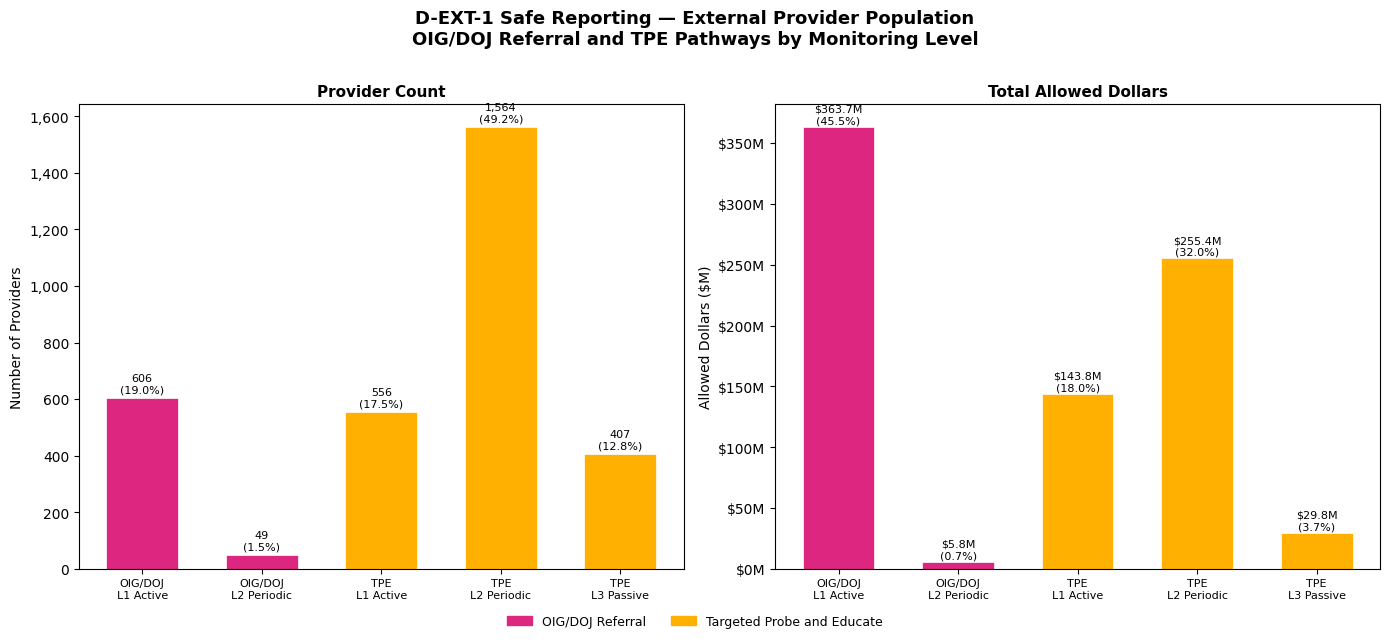


Figure saved: C:\Users\billm\Projects\Medicare\medicare-program-integrity\outputs\figures\safe_reporting_summary_v1.png


In [14]:
# DEXT1-06-VIZ-01
# Visualization — external reporting population summary
# Two-panel: provider count and allowed dollars by pathway x monitoring level

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

# ── Prepare plot data ─────────────────────────────────────────────────────
plot_df = df_summary.copy()

# Shorten labels for display
plot_df["pathway_short"] = plot_df["pathway"].map({
    "OIG/DOJ Referral"          : "OIG/DOJ",
    "Targeted Probe and Educate": "TPE",
})
plot_df["level_short"] = plot_df["monitoring_level"].map({
    "Level 1 — Active Surveillance"  : "L1 Active",
    "Level 2 — Periodic Review"      : "L2 Periodic",
    "Level 3 — Passive Surveillance" : "L3 Passive",
})
plot_df["group_label"] = plot_df["pathway_short"] + "\n" + plot_df["level_short"]

# ── Color mapping ─────────────────────────────────────────────────────────
color_map = {
    "OIG/DOJ": COLOR_OIG,
    "TPE"    : COLOR_TPE,
}
colors = plot_df["pathway_short"].map(color_map).tolist()

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "D-EXT-1 Safe Reporting — External Provider Population\n"
    "OIG/DOJ Referral and TPE Pathways by Monitoring Level",
    fontsize=13, fontweight="bold", y=1.01
)

x = np.arange(len(plot_df))
bar_width = 0.6

# ── Panel 1 — Provider Count ──────────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(x, plot_df["provider_count"], width=bar_width,
                color=colors, edgecolor="white", linewidth=0.5)
ax1.set_title("Provider Count", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["group_label"], fontsize=8)
ax1.set_ylabel("Number of Providers")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, val, pct in zip(bars1, plot_df["provider_count"], plot_df["pct_providers"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f"{val:,}\n({pct}%)",
             ha="center", va="bottom", fontsize=8)

# ── Panel 2 — Allowed Dollars ─────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(x, plot_df["total_allowed_M"], width=bar_width,
                color=colors, edgecolor="white", linewidth=0.5)
ax2.set_title("Total Allowed Dollars", fontsize=11, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(plot_df["group_label"], fontsize=8)
ax2.set_ylabel("Allowed Dollars ($M)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
for bar, val, pct in zip(bars2, plot_df["total_allowed_M"], plot_df["pct_dollars"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"${val:.1f}M\n({pct}%)",
             ha="center", va="bottom", fontsize=8)

# ── Legend ────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=COLOR_OIG, label="OIG/DOJ Referral"),
    mpatches.Patch(color=COLOR_TPE, label="Targeted Probe and Educate"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────
fig_path = FIGURES_DIR / "safe_reporting_summary_v1.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved: {fig_path}")

In [15]:
# DEXT1-07-OUTPUT-01
# Write output files and verify round-trip

# ── Write parquet files ───────────────────────────────────────────────────
df_safe.to_parquet(F_SAFE_PROVIDERS, index=False)
df_summary.to_parquet(F_SAFE_SUMMARY, index=False)

print("Output files written.")

# ── Round-trip verification ───────────────────────────────────────────────
rt_providers = pd.read_parquet(F_SAFE_PROVIDERS)
rt_summary   = pd.read_parquet(F_SAFE_SUMMARY)

print(f"\nsafe_reporting_providers_v1.parquet")
print(f"  Rows    : {rt_providers.shape[0]:,}")
print(f"  Columns : {rt_providers.shape[1]}")
print(f"  Columns : {rt_providers.columns.tolist()}")

print(f"\nsafe_reporting_summary_v1.parquet")
print(f"  Rows    : {rt_summary.shape[0]:,}")
print(f"  Columns : {rt_summary.shape[1]}")
print(f"  Columns : {rt_summary.columns.tolist()}")

# ── Assertions ────────────────────────────────────────────────────────────
assert rt_providers.shape[0] == 3182, "Provider count mismatch"
assert rt_summary.shape[0]   == 5,    "Summary row count mismatch"
assert rt_providers["disclaimer"].notna().all(), "Missing disclaimer rows"
assert rt_summary["disclaimer"].notna().all(),   "Missing disclaimer rows in summary"

print("\nAll assertions passed.")

Output files written.

safe_reporting_providers_v1.parquet
  Rows    : 3,182
  Columns : 9
  Columns : ['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'pathway', 'monitoring_level', 'allowed_dollars_sum', 'composite_score', 'disclaimer', 'evidence_tag']

safe_reporting_summary_v1.parquet
  Rows    : 5
  Columns : 10
  Columns : ['pathway', 'monitoring_level', 'provider_count', 'total_allowed', 'mean_composite', 'pct_providers', 'pct_dollars', 'evidence_tag', 'disclaimer', 'total_allowed_M']

All assertions passed.


In [29]:
# DEXT1-08-EVIDENCE-01a
# Evidence log — E-DEXT1-01 through E-DEXT1-04

print("=" * 70)
print("D-EXT-1 Safe Reporting — Evidence Summary (1 of 2)")
print("=" * 70)

# ── E-DEXT1-01 ────────────────────────────────────────────────────────────
oig_count = int((df_ext["pathway"] == "OIG/DOJ Referral").sum())
tpe_count = int((df_ext["pathway"] == "Targeted Probe and Educate").sum())
print(f"\nE-DEXT1-01 | df_ext — filtered from df_pathway")
print(f"  Result   : {len(df_ext):,} providers in external pathways")
print(f"             OIG/DOJ Referral: {oig_count:,} | TPE: {tpe_count:,}")
print(f"  Tag      : O — Observed (pathway assignments from D-PI-2)")

# ── E-DEXT1-02 ────────────────────────────────────────────────────────────
xtab = pd.crosstab(df_work["pathway"], df_work["monitoring_level"])
oig_l1 = int(xtab.loc["OIG/DOJ Referral", "Level 1 — Active Surveillance"])
oig_l2 = int(xtab.loc["OIG/DOJ Referral", "Level 2 — Periodic Review"])
tpe_l1 = int(xtab.loc["Targeted Probe and Educate", "Level 1 — Active Surveillance"])
tpe_l2 = int(xtab.loc["Targeted Probe and Educate", "Level 2 — Periodic Review"])
tpe_l3 = int(xtab.loc["Targeted Probe and Educate", "Level 3 — Passive Surveillance"])
print(f"\nE-DEXT1-02 | df_work — df_ext merged with monitoring_level")
print(f"  Result   : {df_work.shape[0]:,} rows | {df_work.shape[1]} columns | 0 unmatched")
print(f"             OIG L1: {oig_l1} | OIG L2: {oig_l2} | OIG L3: 0")
print(f"             TPE L1: {tpe_l1} | TPE L2: {tpe_l2} | TPE L3: {tpe_l3}")
print(f"  Tag      : D — Derived (merge of D-PI-2 and D-OPS-1 outputs)")

# ── E-DEXT1-03 ────────────────────────────────────────────────────────────
print(f"\nE-DEXT1-03 | df_safe — safe column allowlist applied")
print(f"  Result   : {df_safe.shape[0]:,} rows | {df_safe.shape[1]} columns | {df_safe.isnull().sum().sum()} nulls")
print(f"             Columns: {df_safe.columns.tolist()}")
print(f"  Tag      : D — Derived (allowlist filter + disclaimer append)")

# ── E-DEXT1-04 ────────────────────────────────────────────────────────────
total_provs   = int(df_summary["provider_count"].sum())
total_dollars = float(df_summary["total_allowed"].sum()) / 1_000_000
oig_l1_row = df_summary[
    (df_summary["pathway"] == "OIG/DOJ Referral") &
    (df_summary["monitoring_level"] == "Level 1 — Active Surveillance")
].iloc[0]
tpe_l2_row = df_summary[
    (df_summary["pathway"] == "Targeted Probe and Educate") &
    (df_summary["monitoring_level"] == "Level 2 — Periodic Review")
].iloc[0]
print(f"\nE-DEXT1-04 | df_summary — aggregate by pathway x monitoring level")
print(f"  Result   : {df_summary.shape[0]} rows | {df_summary.shape[1]} columns")
print(f"             Total providers : {total_provs:,}")
print(f"             Total dollars   : ${total_dollars:.2f}M")
print(f"             OIG/DOJ L1      : {int(oig_l1_row['provider_count']):,} providers | ${float(oig_l1_row['total_allowed_M']):.2f}M ({float(oig_l1_row['pct_dollars'])}% of dollars)")
print(f"             TPE L2          : {int(tpe_l2_row['provider_count']):,} providers | ${float(tpe_l2_row['total_allowed_M']):.2f}M ({float(tpe_l2_row['pct_dollars'])}% of dollars)")
print(f"  Tag      : D — Derived (grouped aggregation)")

D-EXT-1 Safe Reporting — Evidence Summary (1 of 2)

E-DEXT1-01 | df_ext — filtered from df_pathway
  Result   : 3,182 providers in external pathways
             OIG/DOJ Referral: 655 | TPE: 2,527
  Tag      : O — Observed (pathway assignments from D-PI-2)

E-DEXT1-02 | df_work — df_ext merged with monitoring_level
  Result   : 3,182 rows | 15 columns | 0 unmatched
             OIG L1: 606 | OIG L2: 49 | OIG L3: 0
             TPE L1: 556 | TPE L2: 1564 | TPE L3: 407
  Tag      : D — Derived (merge of D-PI-2 and D-OPS-1 outputs)

E-DEXT1-03 | df_safe — safe column allowlist applied
  Result   : 3,182 rows | 9 columns | 0 nulls
             Columns: ['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'pathway', 'monitoring_level', 'allowed_dollars_sum', 'composite_score', 'disclaimer', 'evidence_tag']
  Tag      : D — Derived (allowlist filter + disclaimer append)

E-DEXT1-04 | df_summary — aggregate by pathway x monitoring level
  Result   : 5 rows | 10 columns
           

In [31]:
# DEXT1-08-EVIDENCE-01b
# Evidence log — E-DEXT1-05 through E-DEXT1-07

print("=" * 70)
print("D-EXT-1 Safe Reporting — Evidence Summary (2 of 2)")
print("=" * 70)

# ── E-DEXT1-05 ────────────────────────────────────────────────────────────
npi_oig_test = str(df_safe[df_safe["pathway"] == "OIG/DOJ Referral"].iloc[0]["Rndrng_NPI"])
npi_tpe_test = str(df_safe[df_safe["pathway"] == "Targeted Probe and Educate"].iloc[0]["Rndrng_NPI"])
res_oig  = cross_reference_tip(npi_oig_test, df_safe)
res_tpe  = cross_reference_tip(npi_tpe_test, df_safe)
res_none = cross_reference_tip("0000000000", df_safe)
print(f"\nE-DEXT1-05 | cross_reference_tip() — tip intake infrastructure")
print(f"  Result   : Function validated on 3 test cases")
print(f"             OIG match : NPI {res_oig['tip_npi']} | {res_oig['monitoring_level']} | score {float(res_oig['composite_score']):.4f} | ${float(res_oig['allowed_dollars']):,.2f}")
print(f"             TPE match : NPI {res_tpe['tip_npi']} | {res_tpe['monitoring_level']} | score {float(res_tpe['composite_score']):.4f} | ${float(res_tpe['allowed_dollars']):,.2f}")
print(f"             Unmatched : {res_none['action']}")
print(f"  Tag      : A — Assumed (no live tip data in RY25/D23 cycle)")

# ── E-DEXT1-06 ────────────────────────────────────────────────────────────
print(f"\nE-DEXT1-06 | safe_reporting_summary_v1.png")
print(f"  Result   : Two-panel chart — provider count and allowed dollars")
print(f"             by pathway x monitoring level | CVD-compliant")
print(f"  Tag      : D — Derived")

# ── E-DEXT1-07 ────────────────────────────────────────────────────────────
print(f"\nE-DEXT1-07 | safe_reporting_providers_v1.parquet")
print(f"             safe_reporting_summary_v1.parquet")
print(f"  Result   : Both files written and round-trip verified")
print(f"             Providers file : {rt_providers.shape[0]:,} rows | {rt_providers.shape[1]} columns")
print(f"             Summary file   : {rt_summary.shape[0]:,} rows | {rt_summary.shape[1]} columns")
print(f"             All assertions passed")
print(f"  Tag      : D — Derived")

print("\n" + "=" * 70)
print("No outputs assert provider intent, fraud, or wrongdoing.")
print("Source: CMS Medicare Part B PUF, RY25/D23")
print("=" * 70)

D-EXT-1 Safe Reporting — Evidence Summary (2 of 2)

E-DEXT1-05 | cross_reference_tip() — tip intake infrastructure
  Result   : Function validated on 3 test cases
             OIG match : NPI 1215003603 | Level 1 — Active Surveillance | score 0.6190 | $93,947,495.11
             TPE match : NPI 1407855240 | Level 2 — Periodic Review | score 0.4082 | $69,171,750.22
             Unmatched : Route to D-PI-1 intake — provider not in external reporting population
  Tag      : A — Assumed (no live tip data in RY25/D23 cycle)

E-DEXT1-06 | safe_reporting_summary_v1.png
  Result   : Two-panel chart — provider count and allowed dollars
             by pathway x monitoring level | CVD-compliant
  Tag      : D — Derived

E-DEXT1-07 | safe_reporting_providers_v1.parquet
             safe_reporting_summary_v1.parquet
  Result   : Both files written and round-trip verified
             Providers file : 3,182 rows | 9 columns
             Summary file   : 5 rows | 10 columns
             All assertio